# Testing Notebook

# Ignore Trainig and Validation Accuracy, those are not objective truth measruements they are more just a guage to see how far the model is from the actual postion of the car
# Also ignore those metrics for the funciton reportFinalMetrics

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import config as cfg
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from Data.data_loading import load_and_preprocess_data, create_tensor_from_dataframe, create_sequences, create_dataloaders 
from Training.train_matt_csv import Trainer
from Training.basicEval import plotLoss, plotAccuracy, reportFinalMetrics, reportMultiFinalMetrics, plotMultiAccuracy, plotMultiLoss
from Model.model_split import FrameTransformer, print_model_info

from Training.customLoss import ADELoss, FDELoss, RMSELoss

Using GPU


W0505 19:12:40.005000 24460 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
root_dir = os.getcwd()  # Use current working directory as root
data_dir = os.path.join(root_dir, 'Data')
csv_dir = os.path.join(data_dir, 'csv')
csv_sub_dir = os.path.join(data_dir, 'one_csv')
csv_file = os.path.join(csv_dir, 'trimmed_IMG_4097_detections.csv')

print("Data directory: ", data_dir)
print("CSV directory: ", csv_dir)
print("CSV file: ", csv_file)
print("CSV sub-directory: ", csv_sub_dir)


model_dir = os.path.join(root_dir, 'Model')
save_model_dir = os.path.join(model_dir, 'Saved_Model')
print("Model directory: ", model_dir)
print("Saved model directory: ", save_model_dir)


Data directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data
CSV directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv
CSV file:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\csv\trimmed_IMG_4097_detections.csv
CSV sub-directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Data\one_csv
Model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model
Saved model directory:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model


In [3]:
ADE = ADELoss()
FDE = FDELoss()
RMSE = RMSELoss()

In [4]:
df, transformer_max_ids_per_frame, frame_scaler = load_and_preprocess_data(csv_folder=csv_sub_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)


All CSVs now have 297 frames after trimming
Minimum records per ID: 1
Average records per ID: 202.94
Maximum records per ID: 289

Minimum IDs (Vehicles) per frame: 9
Average IDs (Vehicles) per frame: 12.30
Maximum IDs (Vehicles) per frame: 16

After normalization:
X range: 0.0000 to 5.0000
Y range: 0.0000 to 5.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000


IndexError: index 16 is out of bounds for dimension 0 with size 16

# MSE

In [ ]:
# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


In [ ]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses1, val_losses1, train_accs1, val_accs1, epoch_times1 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=nn.MSELoss(), 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


output_csv_path = os.path.join(save_model_dir, 'output.csv')
error_csv_path = os.path.join(save_model_dir, 'errors.csv')

trainScript.export_predictions_to_csv(csv_path=output_csv_path)

trainScript.compute_and_export_errors(csv_path=error_csv_path)



Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/1345 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'mse_model_csv.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

Saving model to:  c:\Users\flyer\OneDrive\Documents\Github\Github-Deep-Learning-Project\Model\Saved_Model\mse_model_csv.pth


TypeError: Trainer.save_model() takes 2 positional arguments but 3 were given

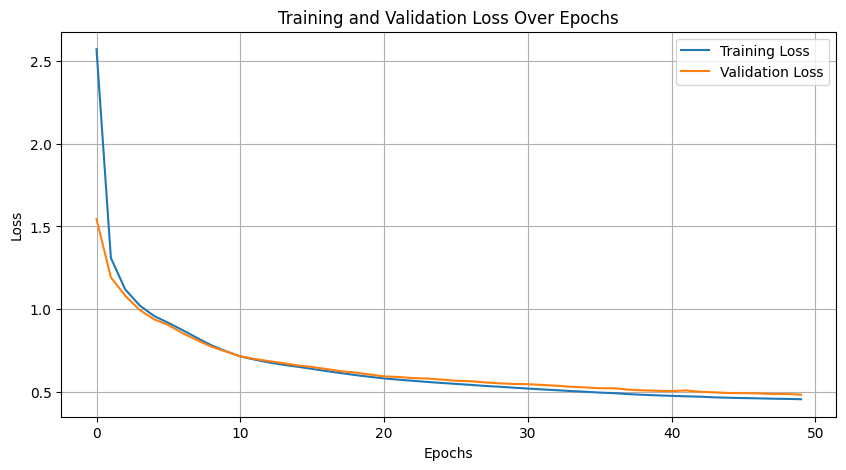

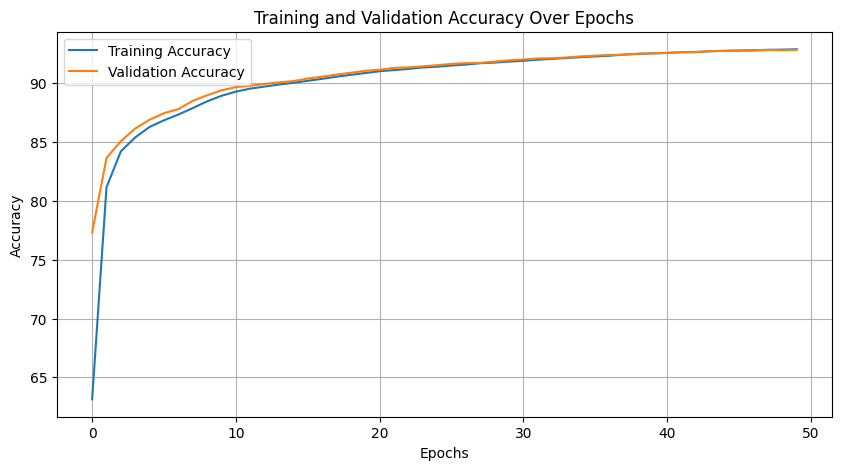

Final Training Accuracy: 0.46%
Final Validation Accuracy: 0.48%
Final Training Loss: 92.8727
Final Validation Loss: 92.8193
Total Training Time: 258.52 seconds


In [ ]:
plotLoss(train_losses1, val_losses1)
plotAccuracy(train_accs1, val_accs1)
reportFinalMetrics(train_losses1, val_losses1, train_accs1, val_accs1, epoch_times1)